# 07. Datos personales (últimos 5 años)

**Fuente:** `data/raw/datos_personales_ultimos_5anios.csv`  
**Salida:** `data/processed/datos_personales_ultimos_5anios.csv`

Datos demograficos base del personal (estado civil, fecha de nacimiento, sexo, origen). Se deriva la edad como variable simple para el perfil.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import _preprocesamiento_comun as pc

pd.set_option('display.max_columns', 100)

## 1. Carga de datos crudos

In [2]:
df = pc.leer_csv('datos_personales_ultimos_5anios.csv', low_memory=False)
df.head()

Leido datos_personales_ultimos_5anios.csv con encoding=utf-8-sig -> 2213 filas, 7 columnas


,IDPERSONA,ESTADOCIVIL,FECHANACIMIENTO,SEXO,PAISORIGEN,PROVINCIAORIGEN,CANTONORIGEN
0,315,C,1946-09-03,M,ECUADOR,CHIMBORAZO,CHUNCHI
1,651104,C,1947-09-16,F,CUBA,LA HABANA,LA HABANA
2,568,S,1949-10-06,M,ECUADOR,GUAYAS,GUAYAQUIL
3,97530,C,1949-10-28,M,VENEZUELA,TRUJILLO,VALERA
4,597,C,1950-10-14,M,ECUADOR,GUAYAS,GUAYAQUIL


## 2. Exploración inicial

In [3]:
pc.resumen(df, 'datos_personales_ultimos_5anios')

--- Resumen datos_personales_ultimos_5anios ---
Dimensiones: 2213 filas x 7 columnas
Filas duplicadas: 0
Columnas con nulos (%):
CANTONORIGEN       0.9
PROVINCIAORIGEN    0.7
ESTADOCIVIL        0.0
dtype: float64


In [4]:
df.dtypes

IDPERSONA          int64
ESTADOCIVIL          str
FECHANACIMIENTO      str
SEXO                 str
PAISORIGEN           str
PROVINCIAORIGEN      str
CANTONORIGEN         str
dtype: object

## 3. Limpieza

In [5]:
df = pc.limpiar_strings(df)
df = pc.quitar_columnas_vacias(df, umbral=0.99)
df = pc.quitar_columnas_constantes(df)

## 5. Tipado de fechas e identificadores

In [6]:
df = pc.castear_fechas(df, ['FECHANACIMIENTO'])
df = pc.castear_enteros(df, ['IDPERSONA'])

## 6. Variable derivada: edad

In [7]:
hoy = pd.Timestamp('2026-08-31')
df['EDAD'] = ((hoy - df['FECHANACIMIENTO']).dt.days // 365.25).astype('Int64')
df['EDAD'].describe()

count       2213.0
mean     41.178039
std      11.419817
min           23.0
25%           32.0
50%           39.0
75%           48.0
max           79.0
Name: EDAD, dtype: Float64

## Gráficos exploratorios

Vistas rápidas para apoyar la construcción del catálogo de variables del perfil (Fase 1-2 de la metodología): estacionalidad/tendencia temporal, categorías dominantes y forma de la distribución de las variables numéricas.

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

**Distribución de edad** del personal (variable derivada EDAD).

<Axes: title={'center': 'Distribución de edad del personal'}>

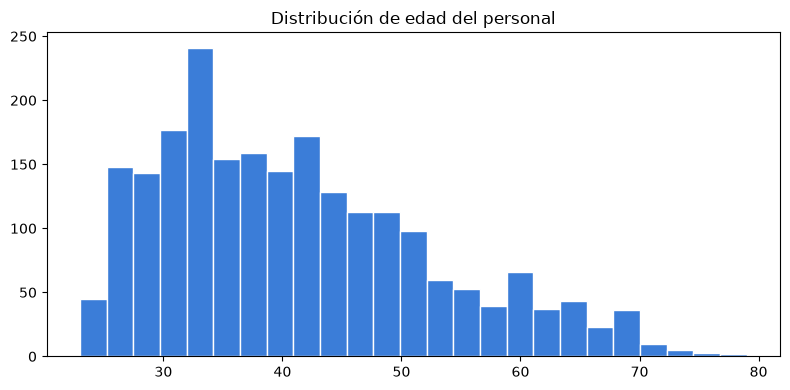

In [9]:
pc.grafico_histograma(df['EDAD'], 'Distribución de edad del personal', bins=25, recorte_percentil=None)

**Distribución por sexo**.

<Axes: title={'center': 'Distribución por sexo'}, xlabel='SEXO'>

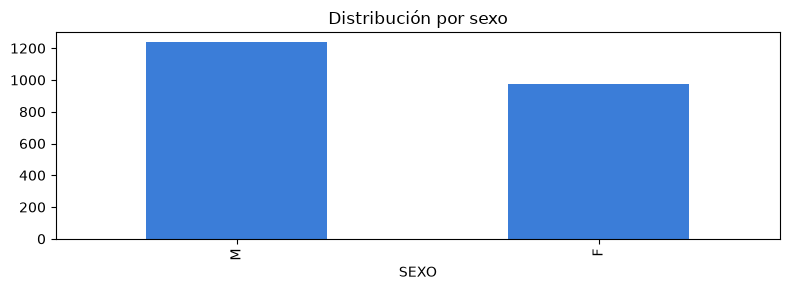

In [10]:
pc.grafico_barras(df['SEXO'], 'Distribución por sexo', horizontal=False)

**Distribución por estado civil**.

<Axes: title={'center': 'Distribución por estado civil'}, xlabel='ESTADOCIVIL'>

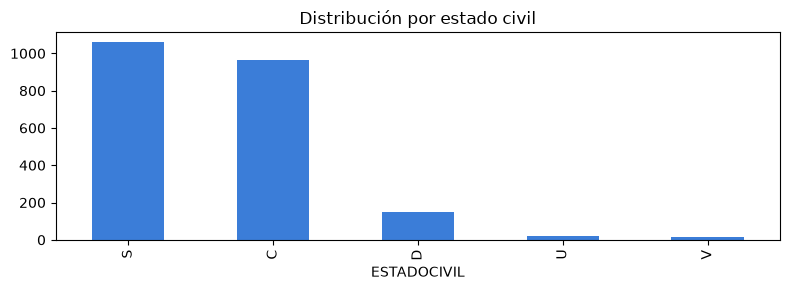

In [11]:
pc.grafico_barras(df['ESTADOCIVIL'], 'Distribución por estado civil', horizontal=False)

**Provincias de origen más frecuentes**.

<Axes: title={'center': 'Top 10 provincias de origen'}, ylabel='PROVINCIAORIGEN'>

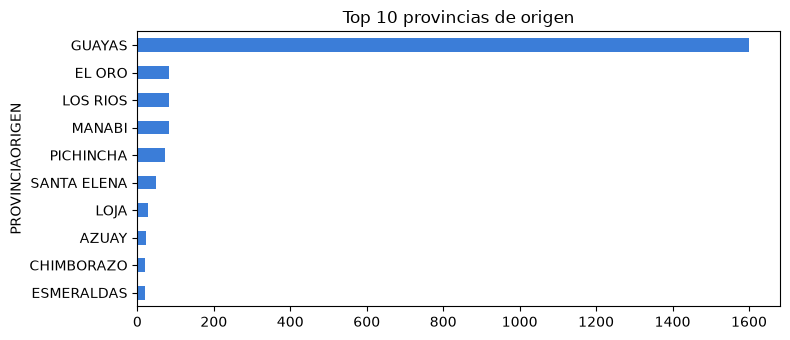

In [12]:
pc.grafico_barras(df['PROVINCIAORIGEN'], 'Top 10 provincias de origen', top=10)

## 7. Verificación final

In [13]:
pc.resumen(df, 'datos_personales_ultimos_5anios (procesado)')
df.head()

--- Resumen datos_personales_ultimos_5anios (procesado) ---
Dimensiones: 2213 filas x 8 columnas
Filas duplicadas: 0
Columnas con nulos (%):
CANTONORIGEN       0.9
PROVINCIAORIGEN    0.7
ESTADOCIVIL        0.0
dtype: float64


,IDPERSONA,ESTADOCIVIL,FECHANACIMIENTO,SEXO,PAISORIGEN,PROVINCIAORIGEN,CANTONORIGEN,EDAD
0,315,C,1946-09-03,M,ECUADOR,CHIMBORAZO,CHUNCHI,79
1,651104,C,1947-09-16,F,CUBA,LA HABANA,LA HABANA,78
2,568,S,1949-10-06,M,ECUADOR,GUAYAS,GUAYAQUIL,76
3,97530,C,1949-10-28,M,VENEZUELA,TRUJILLO,VALERA,76
4,597,C,1950-10-14,M,ECUADOR,GUAYAS,GUAYAQUIL,75


## 8. Guardado en data/processed

In [14]:
pc.guardar_procesado(df, 'datos_personales_ultimos_5anios.csv')

Guardado: D:\Proyecto_Tesis\data\processed\datos_personales_ultimos_5anios.csv (2213 filas x 8 columnas)


WindowsPath('D:/Proyecto_Tesis/data/processed/datos_personales_ultimos_5anios.csv')